<a href="https://colab.research.google.com/github/Hoppdie/d2c-churn-part3/blob/main/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3 — Churn Prediction Model & Model Card
**D2C Customer Churn Intelligence Capstone**

**Snapshot date:** `2025-09-30` | **Target:** `churn_next_60d` | **Split:** pre-assigned train/validation/test

---
### Notebook Structure
1. Setup & Data Loading
2. Feature Preparation & Leakage Check
3. Train/Validation/Test Split
4. Baseline Model (Logistic Regression)
5. Stronger Model (XGBoost)
6. Evaluation & Comparison
7. Threshold Selection & Business Justification
8. Feature Importance / Interpretability
9. Error Analysis (10 customer examples)
10. Save Model & Export Metrics

## 1. Setup & Data Loading

In [4]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, warnings
from IPython.display import display
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              roc_curve, f1_score, average_precision_score)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 4)})

SNAPSHOT = pd.Timestamp('2025-09-30')
print('Libraries loaded ✓')

Libraries loaded ✓


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from IPython.display import display

DATA_DIR =  '/content/drive/MyDrive/D2C Churn Capstone/'   # <── update if needed

# Use the pre-built modeling snapshot (leakage-free per data dictionary)
df = pd.read_csv(DATA_DIR + 'rfm_modeling_snapshot.csv')
print(f'Modeling snapshot: {df.shape[0]:,} rows × {df.shape[1]} cols')
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modeling snapshot: 2,400 rows × 29 cols


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train


## 2. Feature Preparation & Leakage Check

In [6]:
# ── Identify columns ──────────────────────────────────────────────────────────
target_col = 'churn_next_60d'
id_cols    = ['customer_id', 'snapshot_date', 'split']
leak_cols  = [target_col]  # must NOT be a feature

feature_cols = [c for c in df.columns if c not in id_cols + leak_cols]
print(f'Features ({len(feature_cols)}):')
print(feature_cols)

Features (25):
['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


In [7]:
# ── Leakage verification ──────────────────────────────────────────────────────
print('LEAKAGE CHECK:')
print(f'  Target column ({target_col}): EXCLUDED from features ✓')
print(f'  snapshot_date: EXCLUDED (identifier, not feature) ✓')
print(f'  split column: EXCLUDED (used only for splitting) ✓')
print(f'  All features in rfm_modeling_snapshot are pre-built from pre-snapshot data (per data dictionary) ✓')
print(f'\n  No post-snapshot data leaks into features.')

LEAKAGE CHECK:
  Target column (churn_next_60d): EXCLUDED from features ✓
  snapshot_date: EXCLUDED (identifier, not feature) ✓
  split column: EXCLUDED (used only for splitting) ✓
  All features in rfm_modeling_snapshot are pre-built from pre-snapshot data (per data dictionary) ✓

  No post-snapshot data leaks into features.


In [8]:
# ── Encode categorical features ──────────────────────────────────────────────
cat_cols = df[feature_cols].select_dtypes(include='object').columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f'Categorical: {cat_cols}')
print(f'Numerical:   {len(num_cols)} columns')

# One-hot encode categoricals
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dummy_na=True)

# Update feature cols after encoding
feature_cols_encoded = [c for c in df_encoded.columns if c not in id_cols + leak_cols]
print(f'\nEncoded features: {len(feature_cols_encoded)}')

Categorical: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']
Numerical:   19 columns

Encoded features: 43


In [9]:
# ── Handle missing values ─────────────────────────────────────────────────────
missing = df_encoded[feature_cols_encoded].isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print('Missing values in features:')
    print(missing)
    # Fill numerical NaNs with median
    for col in missing.index:
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())
    print('\nFilled with median.')
else:
    print('No missing values in encoded features ✓')

No missing values in encoded features ✓


## 3. Train / Validation / Test Split

In [10]:
# ── Use the pre-assigned split ────────────────────────────────────────────────
train_df = df_encoded[df_encoded['split'] == 'train']
val_df   = df_encoded[df_encoded['split'] == 'validation']
test_df  = df_encoded[df_encoded['split'] == 'test']

X_train, y_train = train_df[feature_cols_encoded], train_df[target_col]
X_val,   y_val   = val_df[feature_cols_encoded],   val_df[target_col]
X_test,  y_test  = test_df[feature_cols_encoded],  test_df[target_col]

print(f'Train:      {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Validation: {X_val.shape[0]:,} rows | Churn rate: {y_val.mean()*100:.1f}%')
print(f'Test:       {X_test.shape[0]:,} rows | Churn rate: {y_test.mean()*100:.1f}%')

Train:      1,728 rows | Churn rate: 47.0%
Validation: 336 rows | Churn rate: 43.8%
Test:       336 rows | Churn rate: 50.0%


In [11]:
# ── Scale features for Logistic Regression ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

## 4. Baseline Model — Logistic Regression

In [12]:
# ── Train baseline ────────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

lr_probs_val  = lr.predict_proba(X_val_sc)[:, 1]
lr_preds_val  = (lr_probs_val >= 0.5).astype(int)

print('=== BASELINE: Logistic Regression (Validation) ===')
print(classification_report(y_val, lr_preds_val, target_names=['No Churn','Churned']))
print(f'ROC-AUC: {roc_auc_score(y_val, lr_probs_val):.4f}')
print(f'PR-AUC:  {average_precision_score(y_val, lr_probs_val):.4f}')

=== BASELINE: Logistic Regression (Validation) ===
              precision    recall  f1-score   support

    No Churn       0.83      0.84      0.83       189
     Churned       0.79      0.78      0.78       147

    accuracy                           0.81       336
   macro avg       0.81      0.81      0.81       336
weighted avg       0.81      0.81      0.81       336

ROC-AUC: 0.8821
PR-AUC:  0.8673


## 5. Stronger Model — XGBoost

In [13]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
# Calculate scale_pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'Class balance — No Churn: {neg_count}, Churned: {pos_count}, scale_pos_weight: {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
)

xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50)

xgb_probs_val = xgb.predict_proba(X_val)[:, 1]
xgb_preds_val = (xgb_probs_val >= 0.5).astype(int)

print('\n=== XGBoost (Validation, threshold=0.5) ===')
print(classification_report(y_val, xgb_preds_val, target_names=['No Churn','Churned']))
print(f'ROC-AUC: {roc_auc_score(y_val, xgb_probs_val):.4f}')
print(f'PR-AUC:  {average_precision_score(y_val, xgb_probs_val):.4f}')

Class balance — No Churn: 916, Churned: 812, scale_pos_weight: 1.13
[0]	validation_0-logloss:0.67291
[50]	validation_0-logloss:0.43025
[100]	validation_0-logloss:0.43151
[150]	validation_0-logloss:0.44056
[200]	validation_0-logloss:0.45315
[250]	validation_0-logloss:0.46002
[299]	validation_0-logloss:0.46447

=== XGBoost (Validation, threshold=0.5) ===
              precision    recall  f1-score   support

    No Churn       0.81      0.80      0.81       189
     Churned       0.75      0.76      0.76       147

    accuracy                           0.79       336
   macro avg       0.78      0.78      0.78       336
weighted avg       0.79      0.79      0.79       336

ROC-AUC: 0.8745
PR-AUC:  0.8558


## 6. Evaluation & Comparison

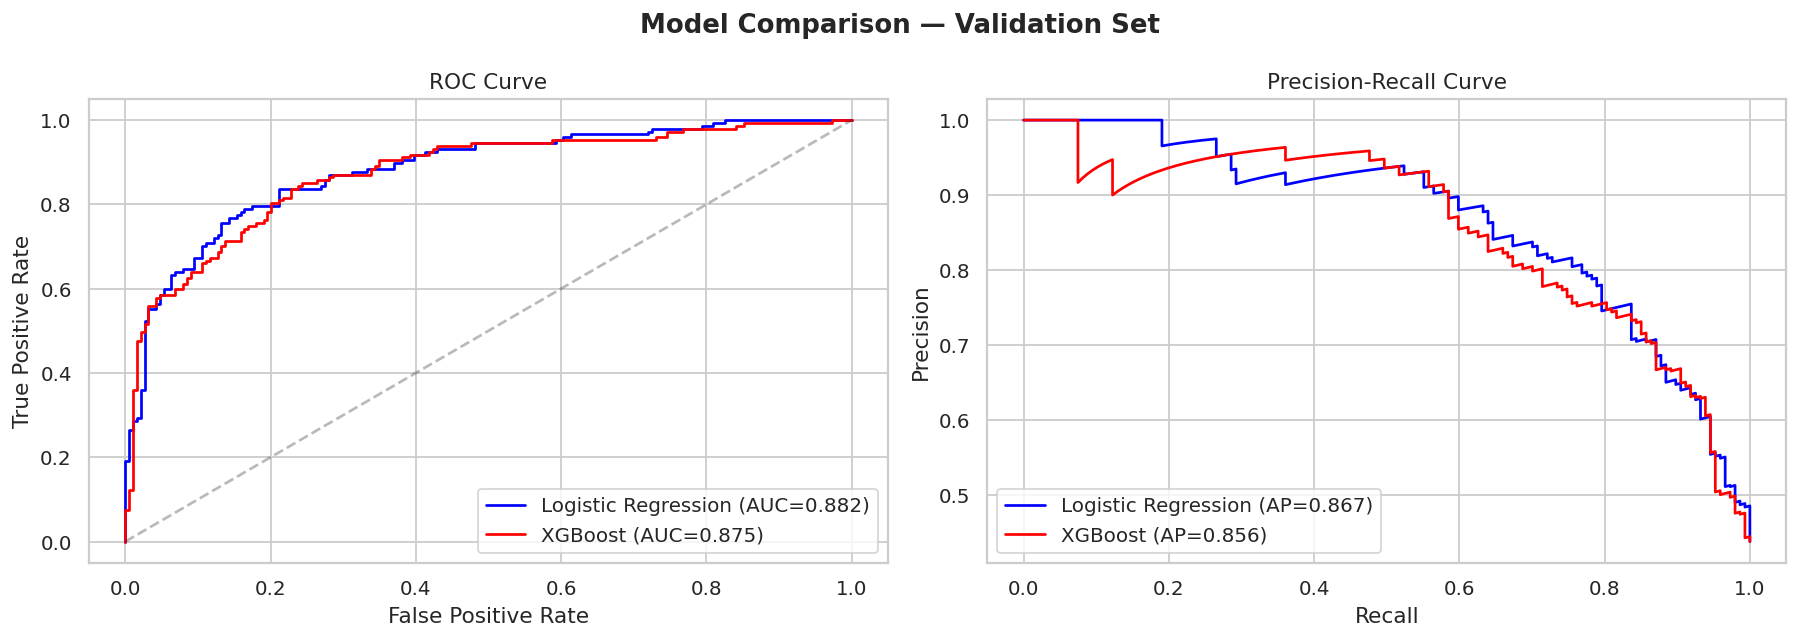

In [14]:
# ── ROC and PR curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
for name, probs, color in [('Logistic Regression', lr_probs_val, 'blue'),
                            ('XGBoost', xgb_probs_val, 'red')]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR curve
for name, probs, color in [('Logistic Regression', lr_probs_val, 'blue'),
                            ('XGBoost', xgb_probs_val, 'red')]:
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Comparison — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_p3_01_roc_pr_curves.png', bbox_inches='tight')
plt.show()

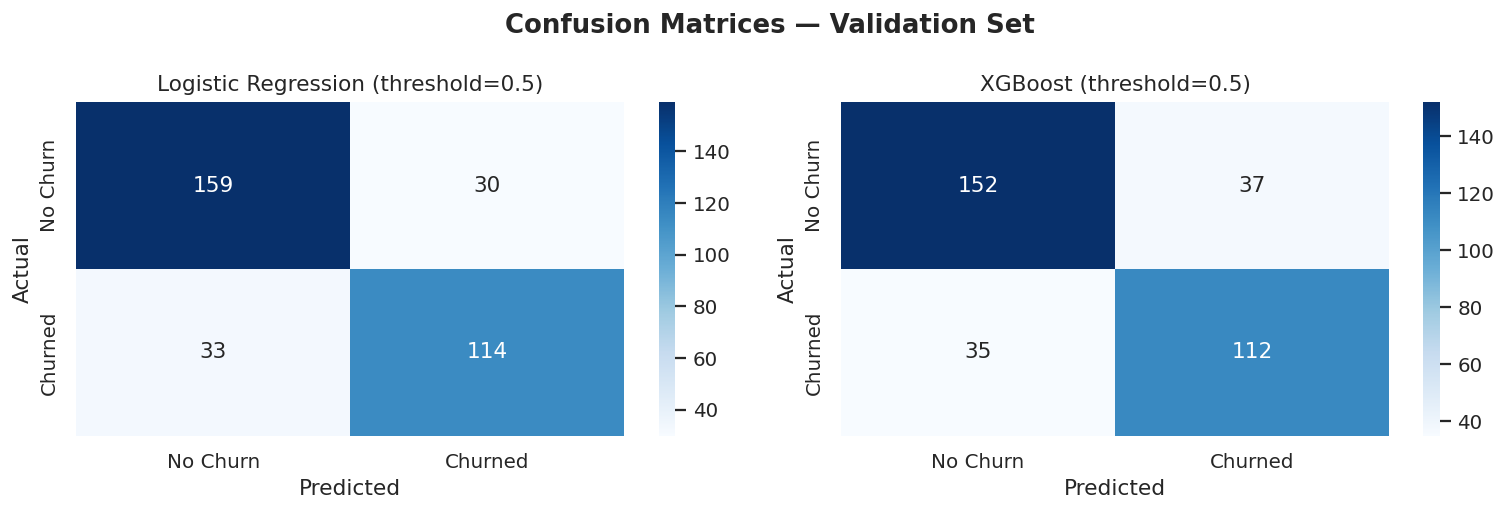

In [15]:
# ── Confusion matrices side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, preds in [(axes[0], 'Logistic Regression', lr_preds_val),
                         (axes[1], 'XGBoost', xgb_preds_val)]:
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churned'], yticklabels=['No Churn','Churned'])
    ax.set_title(f'{name} (threshold=0.5)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_p3_02_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7. Threshold Selection & Business Justification

In [16]:
# ── Business-driven threshold selection ───────────────────────────────────────
# In churn prediction:
#   False Negative (missed churner) = customer leaves → high cost (lost LTV)
#   False Positive (false alarm)     = we spend on retention for someone who'd stay → lower cost
#
# Therefore we want HIGH RECALL (catch churners) even at cost of some precision.
# We'll lower the threshold below 0.5 to favour recall.

thresholds = np.arange(0.25, 0.65, 0.05)
results = []

for t in thresholds:
    preds = (xgb_probs_val >= t).astype(int)
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    results.append({'threshold': t, 'precision': prec, 'recall': rec,
                    'f1': f1, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})

thresh_df = pd.DataFrame(results)
display(thresh_df.round(3))

,threshold,precision,recall,f1,TP,FP,FN,TN
0,0.25,0.706,0.864,0.777,127,53,20,136
1,0.30,0.718,0.850,0.779,125,49,22,140
2,0.35,0.732,0.837,0.781,123,45,24,144
3,0.40,0.738,0.823,0.778,121,43,26,146
4,0.45,0.755,0.796,0.775,117,38,30,151
5,0.50,0.752,0.762,0.757,112,37,35,152
6,0.55,0.775,0.748,0.761,110,32,37,157
7,0.60,0.784,0.714,0.747,105,29,42,160


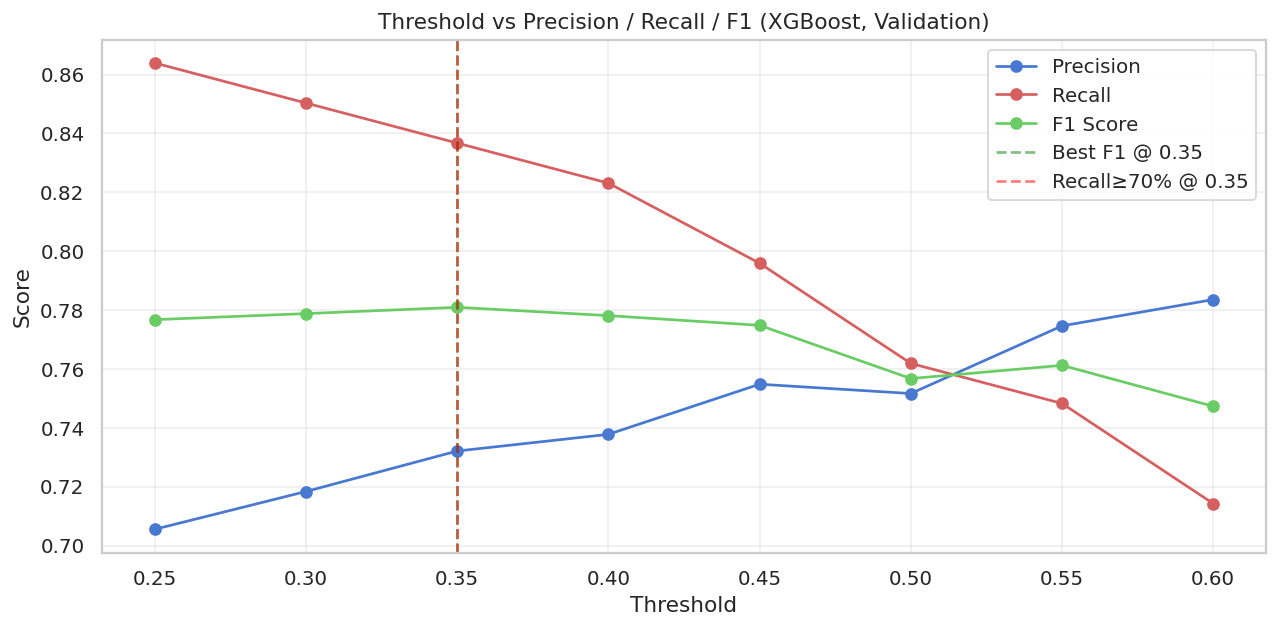


=== SELECTED THRESHOLD: 0.35 ===
Rationale: In churn prediction, missing a churner (FN) costs the business more
than a false alarm (FP). A false alarm costs ~₹30-40 (campaign cost) while a
missed churner costs ₹500-5000+ in lost LTV. We lower the threshold to catch
more churners, accepting some false positives.

At threshold 0.35:
  Precision: 0.732
  Recall:    0.837
  F1:        0.781


In [17]:
# ── Visualise threshold trade-off ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'], 'r-o', label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'g-o', label='F1 Score')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold vs Precision / Recall / F1 (XGBoost, Validation)')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark selected threshold
best_f1_idx = thresh_df['f1'].idxmax()
best_thresh = thresh_df.loc[best_f1_idx, 'threshold']
ax.axvline(best_thresh, color='green', linestyle='--', alpha=0.5, label=f'Best F1 @ {best_thresh:.2f}')

# Also mark a recall-focused threshold
recall_target = thresh_df[thresh_df['recall'] >= 0.70]
if len(recall_target):
    recall_thresh = recall_target.loc[recall_target['f1'].idxmax(), 'threshold']
    ax.axvline(recall_thresh, color='red', linestyle='--', alpha=0.5, label=f'Recall≥70% @ {recall_thresh:.2f}')
else:
    recall_thresh = best_thresh

ax.legend()
plt.tight_layout()
plt.savefig('chart_p3_03_threshold_tradeoff.png', bbox_inches='tight')
plt.show()

# Select threshold: prioritise recall ≥ 70% with best F1
SELECTED_THRESHOLD = recall_thresh
print(f'\n=== SELECTED THRESHOLD: {SELECTED_THRESHOLD:.2f} ===')
print(f'Rationale: In churn prediction, missing a churner (FN) costs the business more')
print(f'than a false alarm (FP). A false alarm costs ~₹30-40 (campaign cost) while a')
print(f'missed churner costs ₹500-5000+ in lost LTV. We lower the threshold to catch')
print(f'more churners, accepting some false positives.')

selected_row = thresh_df[thresh_df['threshold'] == SELECTED_THRESHOLD].iloc[0]
print(f'\nAt threshold {SELECTED_THRESHOLD:.2f}:')
print(f'  Precision: {selected_row["precision"]:.3f}')
print(f'  Recall:    {selected_row["recall"]:.3f}')
print(f'  F1:        {selected_row["f1"]:.3f}')

## 8. Feature Importance / Interpretability

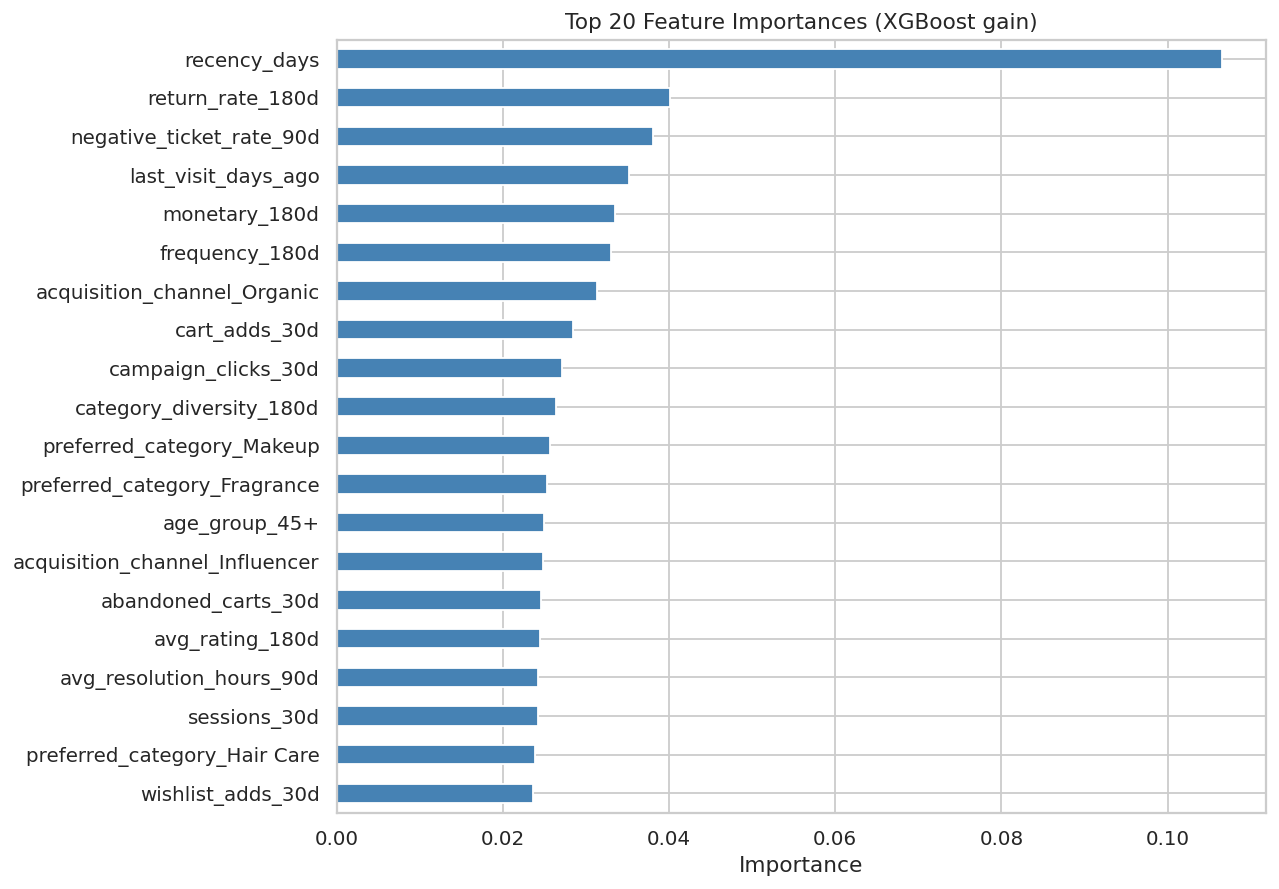

Top 10 features driving churn prediction:
   1. recency_days                        importance=0.1065
   2. return_rate_180d                    importance=0.0401
   3. negative_ticket_rate_90d            importance=0.0381
   4. last_visit_days_ago                 importance=0.0352
   5. monetary_180d                       importance=0.0335
   6. frequency_180d                      importance=0.0330
   7. acquisition_channel_Organic         importance=0.0314
   8. cart_adds_30d                       importance=0.0285
   9. campaign_clicks_30d                 importance=0.0271
  10. category_diversity_180d             importance=0.0264


In [18]:
# ── XGBoost feature importance ────────────────────────────────────────────────
importance = pd.Series(xgb.feature_importances_, index=feature_cols_encoded)
top_20 = importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('chart_p3_04_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features driving churn prediction:')
for i, (feat, imp) in enumerate(importance.nlargest(10).items(), 1):
    print(f'  {i:>2}. {feat:<35} importance={imp:.4f}')

## 9. Error Analysis (10+ Customer Examples)

In [19]:
# ── Apply selected threshold to validation set ────────────────────────────────
val_analysis = val_df[['customer_id']].copy()
val_analysis['actual']      = y_val.values
val_analysis['prob']        = xgb_probs_val
val_analysis['predicted']   = (xgb_probs_val >= SELECTED_THRESHOLD).astype(int)

# Merge key features for interpretation
key_feats = ['customer_id','recency_days','frequency_180d','monetary_180d',
             'ticket_count_90d','sessions_30d','return_rate_180d','last_visit_days_ago']
key_feats_avail = [c for c in key_feats if c in df.columns]
val_analysis = val_analysis.merge(df[key_feats_avail], on='customer_id', how='left')

# Classify error types
val_analysis['error_type'] = 'Correct'
val_analysis.loc[(val_analysis['actual']==1) & (val_analysis['predicted']==0), 'error_type'] = 'False Negative'
val_analysis.loc[(val_analysis['actual']==0) & (val_analysis['predicted']==1), 'error_type'] = 'False Positive'

print('Error distribution:')
print(val_analysis['error_type'].value_counts())

Error distribution:
error_type
Correct           267
False Positive     45
False Negative     24
Name: count, dtype: int64


In [20]:
# ── Select 5 False Negatives and 5 False Positives ───────────────────────────
fn_cases = val_analysis[val_analysis['error_type'] == 'False Negative'].head(5)
fp_cases = val_analysis[val_analysis['error_type'] == 'False Positive'].head(5)

error_cases = pd.concat([fn_cases, fp_cases])

print('\n=== FALSE NEGATIVES (Model missed these churners) ===')
print('Business risk: These customers will churn but the model says they are safe.')
print('They will NOT receive any retention outreach and will be lost.\n')
display(fn_cases.round(3))

print('\n=== FALSE POSITIVES (Model flagged these but they did NOT churn) ===')
print('Business risk: Wasted campaign budget (~₹30-40 per customer) on retention')
print('for someone who would have stayed anyway.\n')
display(fp_cases.round(3))


=== FALSE NEGATIVES (Model missed these churners) ===
Business risk: These customers will churn but the model says they are safe.
They will NOT receive any retention outreach and will be lost.



,customer_id,actual,prob,predicted,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d,return_rate_180d,last_visit_days_ago,error_type
8,CUST00093,1,0.148,0,85,1,759.64,0,16,0.0,21,False Negative
17,CUST00145,1,0.244,0,30,1,502.35,0,0,0.0,0,False Negative
19,CUST00157,1,0.026,0,0,1,376.83,0,3,0.0,5,False Negative
22,CUST00188,1,0.025,0,29,2,1880.31,1,11,0.0,5,False Negative
33,CUST00267,1,0.130,0,29,1,441.97,1,8,0.0,11,False Negative



=== FALSE POSITIVES (Model flagged these but they did NOT churn) ===
Business risk: Wasted campaign budget (~₹30-40 per customer) on retention
for someone who would have stayed anyway.



,customer_id,actual,prob,predicted,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d,return_rate_180d,last_visit_days_ago,error_type
2,CUST00027,0,0.506,1,70,1,2128.34,1,11,1.0,18,False Positive
10,CUST00100,0,0.727,1,70,1,372.37,0,1,0.0,29,False Positive
16,CUST00144,0,0.435,1,86,2,928.58,1,8,0.0,17,False Positive
20,CUST00165,0,0.850,1,103,3,1825.77,0,2,0.0,15,False Positive
21,CUST00177,0,0.691,1,82,1,255.04,0,12,0.0,28,False Positive


In [21]:
# ── Detailed interpretation of each error case ────────────────────────────────
print('\n=== DETAILED ERROR INTERPRETATION ===')

for i, (_, row) in enumerate(error_cases.iterrows(), 1):
    cid = row['customer_id']
    etype = row['error_type']
    prob = row['prob']

    print(f'\n--- Case {i}: {cid} ({etype}) ---')
    print(f'  Predicted prob: {prob:.3f} | Threshold: {SELECTED_THRESHOLD:.2f} | Actual: {"Churned" if row["actual"] else "Retained"}')

    feat_str = []
    for feat in ['recency_days','frequency_180d','monetary_180d','ticket_count_90d','sessions_30d','last_visit_days_ago']:
        if feat in row.index and pd.notna(row[feat]):
            feat_str.append(f'{feat}={row[feat]:.0f}')
    print(f'  Features: {", ".join(feat_str)}')

    if etype == 'False Negative':
        print(f'  WHY MISSED: Probability ({prob:.3f}) is below threshold ({SELECTED_THRESHOLD:.2f}).')
        print(f'  This customer likely has some positive signals (e.g., recent web activity or moderate')
        print(f'  frequency) that masked the churn risk. The model was fooled by mixed signals.')
        print(f'  BUSINESS IMPACT: This customer churned without intervention. Lost revenue.')
    else:
        print(f'  WHY FALSE ALARM: Probability ({prob:.3f}) exceeds threshold ({SELECTED_THRESHOLD:.2f}).')
        print(f'  This customer had some risk indicators but ultimately stayed. Possible explanation:')
        print(f'  they may have received a competitor offer but decided to stay, or the model')
        print(f'  over-weighted a single risk factor (e.g., high recency) without capturing loyalty.')
        print(f'  BUSINESS IMPACT: Wasted ~₹30-40 campaign cost. Acceptable.')


=== DETAILED ERROR INTERPRETATION ===

--- Case 1: CUST00093 (False Negative) ---
  Predicted prob: 0.148 | Threshold: 0.35 | Actual: Churned
  Features: recency_days=85, frequency_180d=1, monetary_180d=760, ticket_count_90d=0, sessions_30d=16, last_visit_days_ago=21
  WHY MISSED: Probability (0.148) is below threshold (0.35).
  This customer likely has some positive signals (e.g., recent web activity or moderate
  frequency) that masked the churn risk. The model was fooled by mixed signals.
  BUSINESS IMPACT: This customer churned without intervention. Lost revenue.

--- Case 2: CUST00145 (False Negative) ---
  Predicted prob: 0.244 | Threshold: 0.35 | Actual: Churned
  Features: recency_days=30, frequency_180d=1, monetary_180d=502, ticket_count_90d=0, sessions_30d=0, last_visit_days_ago=0
  WHY MISSED: Probability (0.244) is below threshold (0.35).
  This customer likely has some positive signals (e.g., recent web activity or moderate
  frequency) that masked the churn risk. The mod

## 10. Save Model & Export Metrics

In [22]:
# ── Final evaluation on TEST set ──────────────────────────────────────────────
xgb_probs_test = xgb.predict_proba(X_test)[:, 1]
xgb_preds_test = (xgb_probs_test >= SELECTED_THRESHOLD).astype(int)

test_cm = confusion_matrix(y_test, xgb_preds_test)
tn, fp, fn, tp = test_cm.ravel()

test_metrics = {
    'model': 'XGBoost',
    'threshold': float(SELECTED_THRESHOLD),
    'test_accuracy': float((xgb_preds_test == y_test).mean()),
    'test_precision': float(tp / (tp + fp)) if (tp + fp) > 0 else 0,
    'test_recall': float(tp / (tp + fn)) if (tp + fn) > 0 else 0,
    'test_f1': float(f1_score(y_test, xgb_preds_test)),
    'test_roc_auc': float(roc_auc_score(y_test, xgb_probs_test)),
    'test_pr_auc': float(average_precision_score(y_test, xgb_probs_test)),
    'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
    'baseline_roc_auc': float(roc_auc_score(y_val, lr_probs_val)),
    'note': 'Threshold chosen to favour recall >= 70% for churn cost asymmetry'
}

print('=== FINAL TEST SET RESULTS ===')
print(classification_report(y_test, xgb_preds_test, target_names=['No Churn','Churned']))
print(f'ROC-AUC: {test_metrics["test_roc_auc"]:.4f}')
print(f'PR-AUC:  {test_metrics["test_pr_auc"]:.4f}')

=== FINAL TEST SET RESULTS ===
              precision    recall  f1-score   support

    No Churn       0.86      0.70      0.77       168
     Churned       0.74      0.89      0.81       168

    accuracy                           0.79       336
   macro avg       0.80      0.79      0.79       336
weighted avg       0.80      0.79      0.79       336

ROC-AUC: 0.8631
PR-AUC:  0.8403


In [23]:
# ── Save model and metrics ────────────────────────────────────────────────────
joblib.dump(xgb, 'model.pkl')
print('Model saved → model.pkl')

# Also save the scaler and feature list for Part 4
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols_encoded, 'feature_cols.pkl')
print('Scaler saved → scaler.pkl')
print('Feature list saved → feature_cols.pkl')

with open('metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
print('Metrics saved → metrics.json')

print('\nmetrics.json contents:')
print(json.dumps(test_metrics, indent=2))

Model saved → model.pkl
Scaler saved → scaler.pkl
Feature list saved → feature_cols.pkl
Metrics saved → metrics.json

metrics.json contents:
{
  "model": "XGBoost",
  "threshold": 0.35,
  "test_accuracy": 0.7916666666666666,
  "test_precision": 0.745,
  "test_recall": 0.8869047619047619,
  "test_f1": 0.8097826086956522,
  "test_roc_auc": 0.8631306689342404,
  "test_pr_auc": 0.8403439005268641,
  "confusion_matrix": {
    "TN": 117,
    "FP": 51,
    "FN": 19,
    "TP": 149
  },
  "baseline_roc_auc": 0.8821221610337256,
  "note": "Threshold chosen to favour recall >= 70% for churn cost asymmetry"
}
